In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, RobertaModel, RobertaTokenizer
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import math
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.cluster import DBSCAN
from sklearn.utils.class_weight import compute_class_weight
import json
import openai

In [ ]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=False)

Mounted at /content/drive/


In [ ]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv')

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            61834 non-null  object 
 1   country                             61834 non-null  object 
 2   contest_url                         61834 non-null  object 
 3   num_of_contest                      61834 non-null  int64  
 4   is_weekly                           61834 non-null  bool   
 5   rank                                61834 non-null  int64  
 6   score                               61834 non-null  int64  
 7   question_number                     61834 non-null  int64  
 8   question_language                   61834 non-null  object 
 9   question_code                       61834 non-null  object 
 10  number_of_lines                     61834 non-null  int64  
 11  names_set                           61834

In [ ]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'C++']
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_number'] > 2]
leetcode_questions_df = leetcode_questions_df.drop_duplicates(subset=['question_code'])
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['country'].isin(leetcode_questions_df['country'].value_counts().head(2).index)]

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12612 entries, 64 to 61803
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            12612 non-null  object 
 1   country                             12612 non-null  object 
 2   contest_url                         12612 non-null  object 
 3   num_of_contest                      12612 non-null  int64  
 4   is_weekly                           12612 non-null  bool   
 5   rank                                12612 non-null  int64  
 6   score                               12612 non-null  int64  
 7   question_number                     12612 non-null  int64  
 8   question_language                   12612 non-null  object 
 9   question_code                       12612 non-null  object 
 10  number_of_lines                     12612 non-null  int64  
 11  names_set                           12612 non

In [ ]:
leetcode_questions_df.country.value_counts()

,count
country,
India,10865
United States,1747


In [ ]:
leetcode_questions_df.describe()

,num_of_contest,rank,score,question_number,number_of_lines,token_count,variables_count,function_count,loop_count,condition_count,...,function_density,loop_density,condition_density,comment_tokens_density,contest_finish_time_total_seconds,question_finish_time_total_seconds,time_spent_per_question,global_rank_percentile,question_code_length,num_contests_participated
count,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,...,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000,12612.000000
mean,277.618141,611.223834,16.170076,3.419521,51.672772,41.744291,20.769981,2.042975,3.360054,4.487076,...,0.047276,0.087194,0.113584,0.093314,3667.123137,2644.153742,1270.423327,0.034219,1392.486917,6.444656
std,126.184909,344.512547,2.757681,0.493500,34.843605,24.781130,10.210378,2.563672,2.982278,3.670287,...,0.026540,0.074018,0.077667,0.163232,1509.153943,1323.634070,975.268882,0.072692,939.893144,5.669011
min,117.000000,1.000000,8.000000,3.000000,6.000000,10.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,297.000000,99.000000,0.000000,0.000001,107.000000,1.000000
25%,123.000000,320.000000,13.000000,3.000000,31.000000,29.000000,15.000000,1.000000,1.000000,2.000000,...,0.029412,0.035714,0.058824,0.000000,2481.000000,1539.000000,552.000000,0.002230,824.000000,2.000000
50%,371.000000,610.000000,18.000000,3.000000,44.000000,36.000000,18.000000,1.000000,3.000000,4.000000,...,0.040000,0.075472,0.103448,0.000000,3618.000000,2496.500000,1035.500000,0.008753,1203.000000,5.000000
75%,383.000000,901.250000,18.000000,4.000000,63.000000,45.000000,24.000000,2.000000,5.000000,6.000000,...,0.058824,0.117647,0.152542,0.142857,4872.000000,3639.000000,1804.000000,0.030834,1710.000000,9.000000
max,390.000000,1225.000000,20.000000,4.000000,1026.000000,307.000000,152.000000,58.000000,98.000000,105.000000,...,0.407407,1.673913,1.434783,1.000000,9359.000000,5399.000000,5254.000000,1.000000,21789.000000,29.000000


In [ ]:
model_name = "neulab/codebert-cpp"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name)

code_snippets = leetcode_questions_df.question_code.tolist()

# Step 1: Encode the code snippets using CodeBERT
def get_embeddings(code_snippet):
    inputs = tokenizer(code_snippet, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # Use the last hidden state of the [CLS] token as the embedding
    return outputs.last_hidden_state[:, 0, :].numpy()

# Get embeddings for all code snippets
embeddings = np.vstack([get_embeddings(snippet) for snippet in code_snippets])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.54k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at neulab/codebert-cpp and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [ ]:
min_samples = 10 ** (math.floor(math.log10(len(code_snippets))) - 1)

min_samples

1000

In [ ]:
# Step 2: Apply DBSCAN for clustering and outlier detection
dbscan = DBSCAN(eps=0.05, min_samples=min_samples, metric='cosine', n_jobs=-1)
db_labels = dbscan.fit_predict(embeddings)

# Step 3: Identify and handle outliers
outliers = np.where(db_labels == -1)[0]

# Output some statistics
print(f'Removed {len(outliers)} outliers.')
print(f'Retained {len(db_labels) - len(outliers)} code snippets.')

Removed 2784 outliers.
Retained 9828 code snippets.


In [ ]:
# Remove outliers from the DataFrame
leetcode_questions_df.reset_index(drop=True, inplace=True)
leetcode_questions_df = leetcode_questions_df[~leetcode_questions_df.index.isin(outliers)]

leetcode_questions_df.country.value_counts()

,count
country,
India,8582
United States,1246


In [ ]:
X=leetcode_questions_df.drop('country',axis=1)
Y=leetcode_questions_df.country

In [ ]:
X.question_number = X.question_number.astype("category")

In [ ]:
X_train_text, X_test_text, Y_train, y_test = train_test_split(X.question_code, Y, test_size=0.2, random_state=0,stratify=Y)

In [ ]:
X_train_text, X_valid_text, y_train, y_valid = train_test_split(X_train_text, Y_train, test_size=0.125, random_state=0,stratify=Y_train)

In [ ]:
df = pd.concat([X_train_text, y_train], axis=1)

system_prompt = (
    "You are a code style profiler trained to classify programming styles based on regional educational patterns and stylistic conventions. "
    "This task is part of a research simulation in computational authorship profiling. "
    "Your goal is to assign each code snippet to either 'United States' or 'India', based purely on stylistic markers associated with common programming habits observed in datasets from these regions. "
    "These habits may include variable naming conventions (e.g., camelCase vs snake_case), commenting frequency and phrasing, spacing and indentation preferences, control structure usage, verbosity, and structural choices. "
    "You should not consider the semantic content of the code or attempt to infer nationality in a literal or personal sense. "
    "This classification is purely symbolic and intended for academic analysis of code expression patterns. "
    "Always respond with exactly one of the two labels: 'United States' or 'India'. "
    "If the style is ambiguous, choose the label that best aligns with the overall structure and conventions observed."
)


conversations = []

for _, row in df.iterrows():
    user_message = (
    "Below is a code snippet. Based on its stylistic and structural characteristics only—not its logic or content—"
    "please classify it as either originating from the 'United States' or from 'India'. "
    "Focus on naming patterns, spacing, indentation, comment style, and control flow formatting.\n\n"
    "Code:\n"
    f"{row['question_code']}"
    )

    assistant_response = row["country"]

    conversation = {
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_message},
            {"role": "assistant", "content": assistant_response}
        ]
    }
    conversations.append(conversation)

with open("training_data.jsonl", "w") as f:
    for convo in conversations:
        f.write(json.dumps(convo) + "\n")


In [ ]:
df = pd.concat([X_valid_text, y_valid], axis=1)

system_prompt = (
    "You are a code style profiler trained to classify programming styles based on regional educational patterns and stylistic conventions. "
    "This task is part of a research simulation in computational authorship profiling. "
    "Your goal is to assign each code snippet to either 'United States' or 'India', based purely on stylistic markers associated with common programming habits observed in datasets from these regions. "
    "These habits may include variable naming conventions (e.g., camelCase vs snake_case), commenting frequency and phrasing, spacing and indentation preferences, control structure usage, verbosity, and structural choices. "
    "You should not consider the semantic content of the code or attempt to infer nationality in a literal or personal sense. "
    "This classification is purely symbolic and intended for academic analysis of code expression patterns. "
    "Always respond with exactly one of the two labels: 'United States' or 'India'. "
    "If the style is ambiguous, choose the label that best aligns with the overall structure and conventions observed."
)


conversations = []

for _, row in df.iterrows():
    user_message = (
    "Below is a code snippet. Based on its stylistic and structural characteristics only—not its logic or content—"
    "please classify it as either originating from the 'United States' or from 'India'. "
    "Focus on naming patterns, spacing, indentation, comment style, and control flow formatting.\n\n"
    "Code:\n"
    f"{row['question_code']}"
    )

    assistant_response = row["country"]

    conversation = {
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_message},
            {"role": "assistant", "content": assistant_response}
        ]
    }
    conversations.append(conversation)

with open("validation_data.jsonl", "w") as f:
    for convo in conversations:
        f.write(json.dumps(convo) + "\n")


# Finetuned GPT 4 nano

In [ ]:
MODEL_NAME = "ft:gpt-4.1-nano-2025-04-14:personal:cplusplus-country:BdISgVVY"
API_KEY = ""

client = openai.OpenAI(api_key=API_KEY)

In [ ]:
def get_finetuned_llm_prediction(code):
  response = client.chat.completions.create(
      model=MODEL_NAME,
      messages=[
                  {"role": "system", "content": system_prompt},
                  {"role": "user", "content": (
                                    "Below is a code snippet. Based on its stylistic and structural characteristics only—not its logic or content—"
                                    "please classify it as either originating from the 'United States' or from 'India'. "
                                    "Focus on naming patterns, spacing, indentation, comment style, and control flow formatting.\n\n"
                                    "Code:\n"
                                    f"{code}"
                                    )}
               ],
  )

  return response.choices[0].message.content

In [ ]:
y_test_llm = X_test_text.apply(get_finetuned_llm_prediction)

               precision    recall  f1-score   support

        India       0.94      0.97      0.95      1717
United States       0.73      0.57      0.64       249

     accuracy                           0.92      1966
    macro avg       0.84      0.77      0.80      1966
 weighted avg       0.91      0.92      0.91      1966

f1_score_macro :  0.796955046699287
f1_score_weighted :  0.9145587700559396


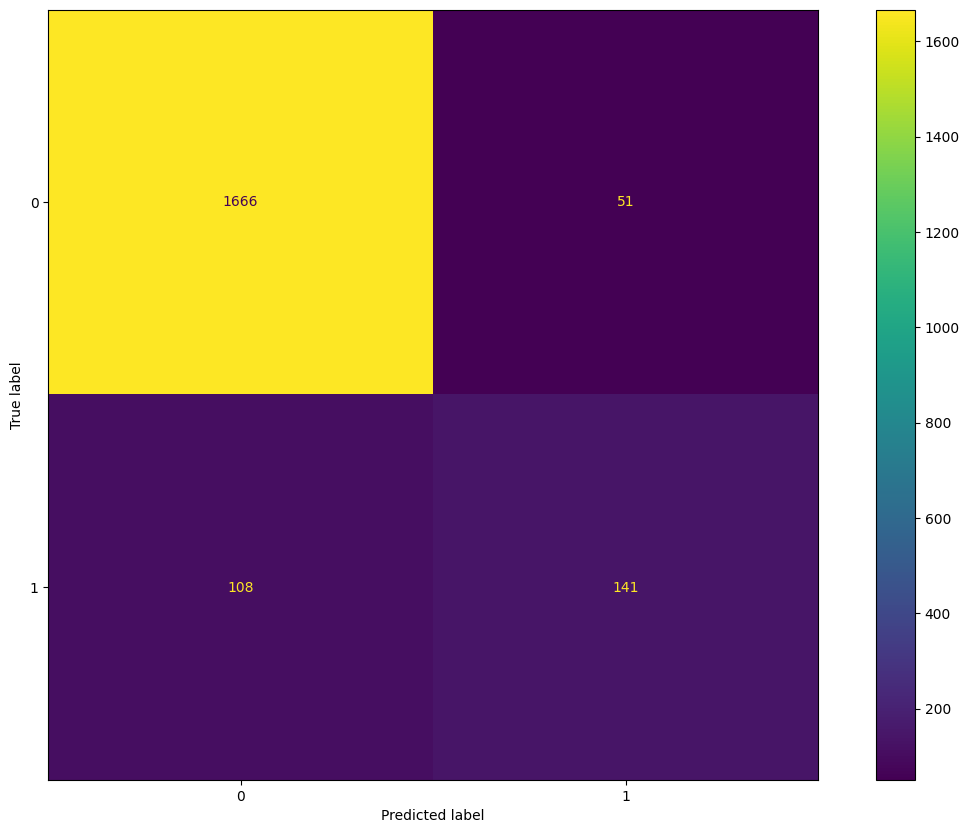

In [ ]:
print(classification_report(y_test, y_test_llm))

print("f1_score_macro : ",f1_score(y_test, y_test_llm, average='macro'))
print("f1_score_weighted : ",f1_score(y_test, y_test_llm, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_llm))

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

# Error Analysis

In [ ]:
test_df = leetcode_questions_df.loc[X_test_text.index]

In [ ]:
test_df['correct'] = y_test_llm == y_test

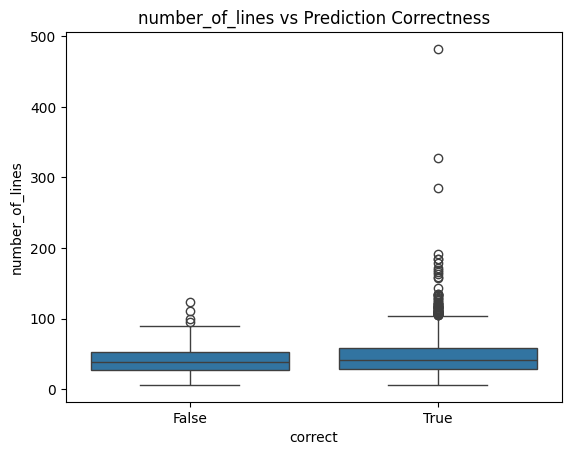

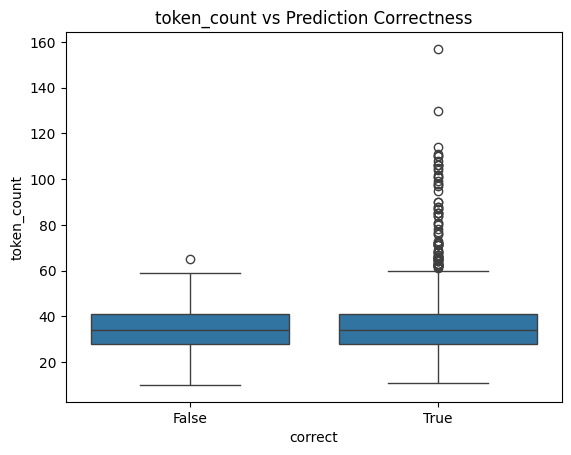

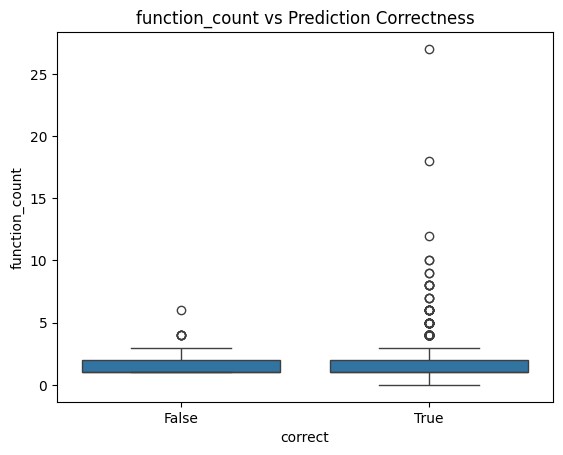

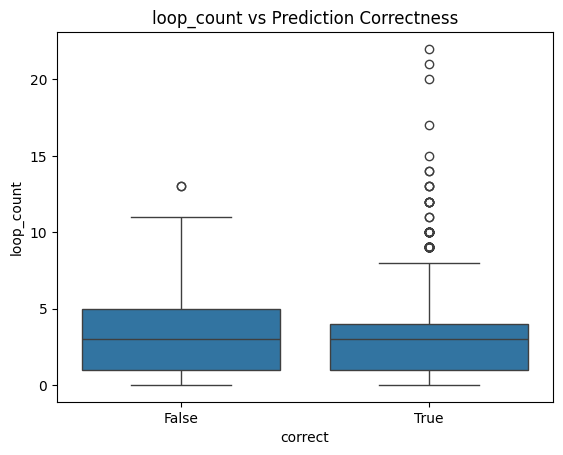

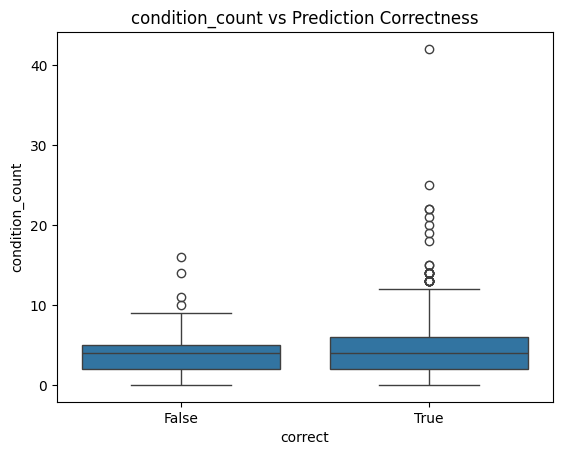

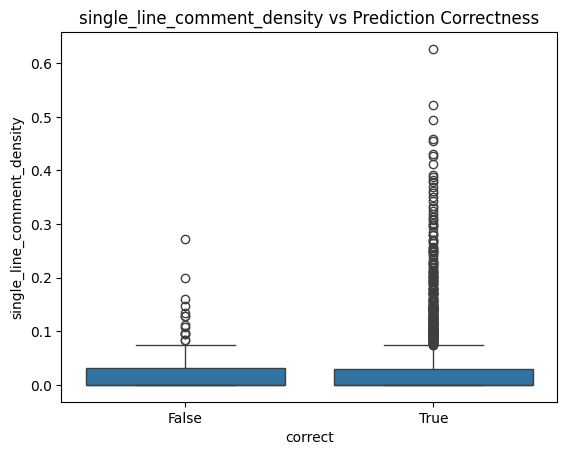

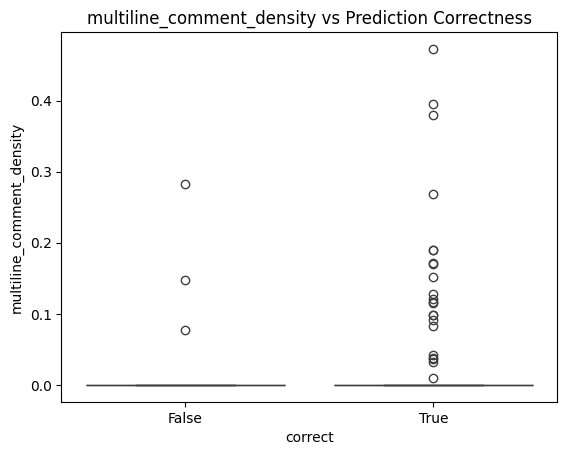

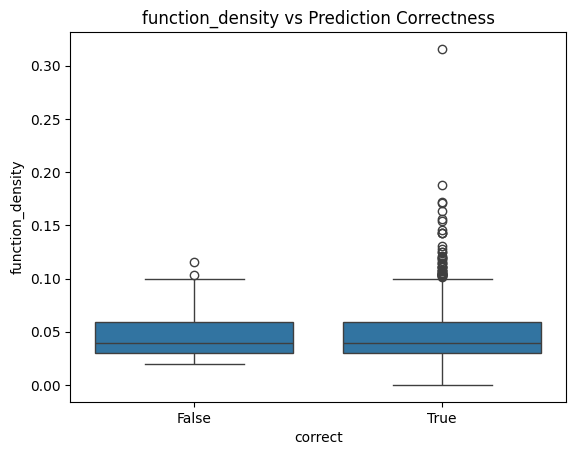

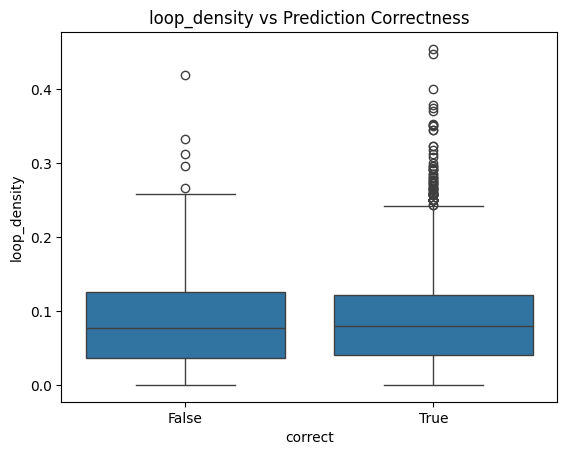

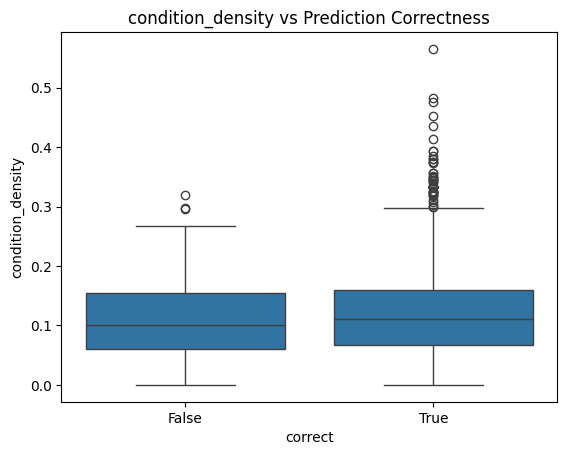

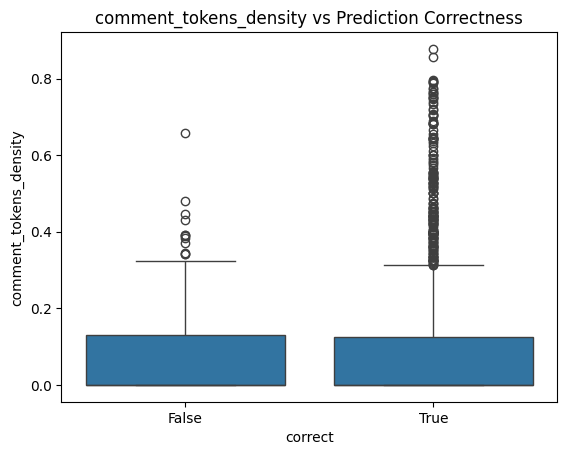

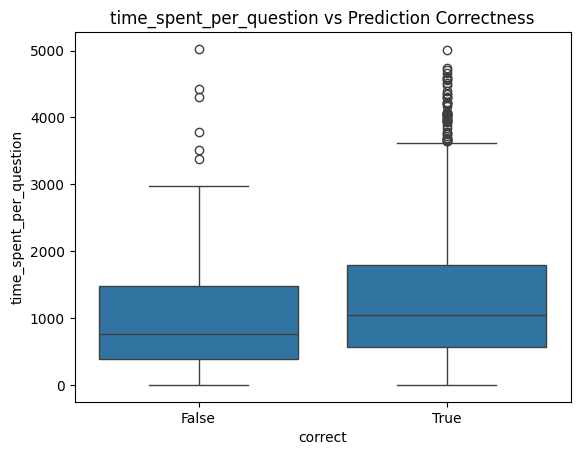

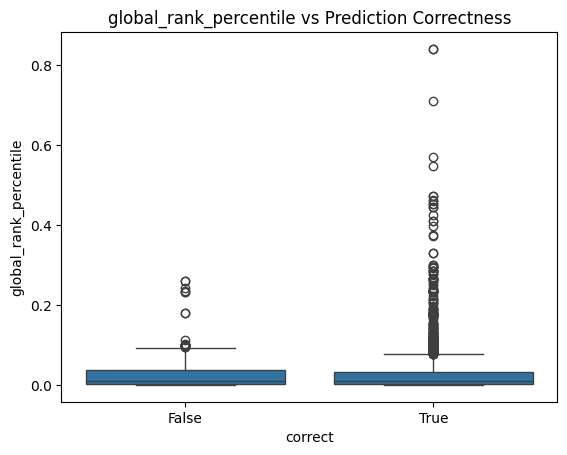

In [ ]:
features_to_plot = [
    'number_of_lines', 'token_count', 'function_count',
    'loop_count', 'condition_count',
    'single_line_comment_density', 'multiline_comment_density',
    'function_density', 'loop_density', 'condition_density',
    'comment_tokens_density', 'time_spent_per_question',
    'global_rank_percentile'
]

for col in features_to_plot:
    sns.boxplot(x='correct', y=col, data=test_df)
    plt.title(f'{col} vs Prediction Correctness')
    plt.show()

In [ ]:
test_df.groupby('correct')[features_to_plot].mean().T.sort_values(by=False, ascending=False)

correct,False,True
time_spent_per_question,1063.512500,1273.939092
number_of_lines,40.893750,47.244186
token_count,34.356250,36.466224
condition_count,3.837500,4.379845
loop_count,3.243750,3.253599
function_count,1.543750,1.705426
condition_density,0.107892,0.120052
loop_density,0.091224,0.089872
comment_tokens_density,0.075202,0.089096
function_density,0.046045,0.046659


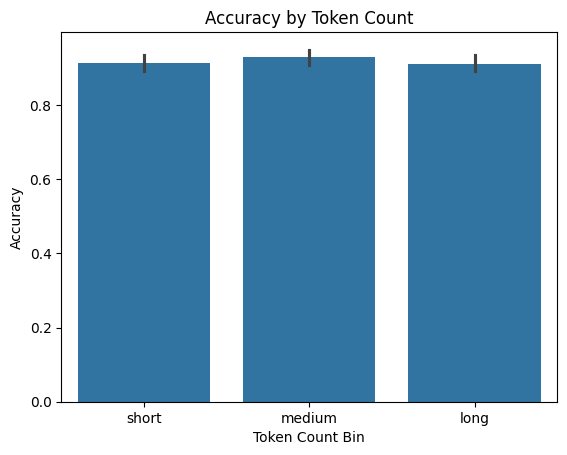

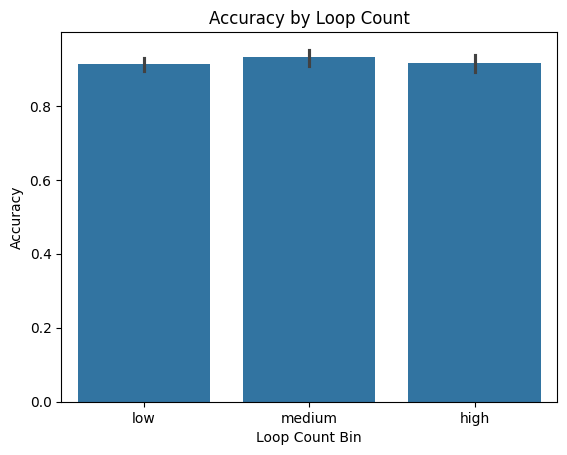

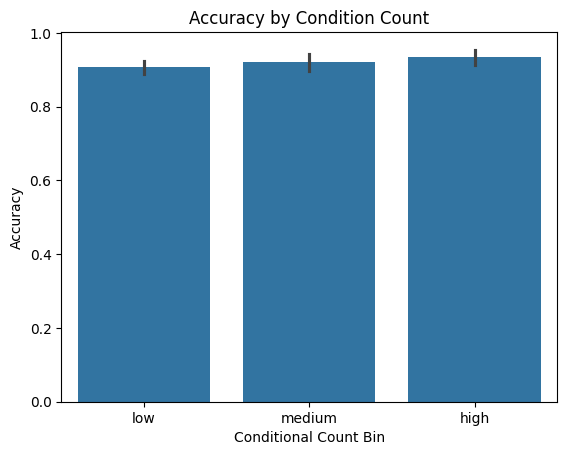

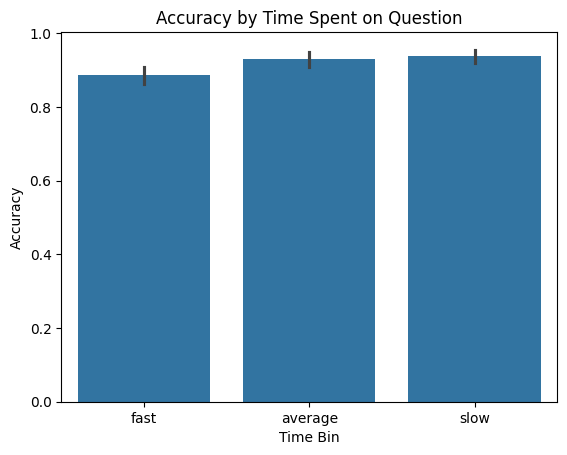

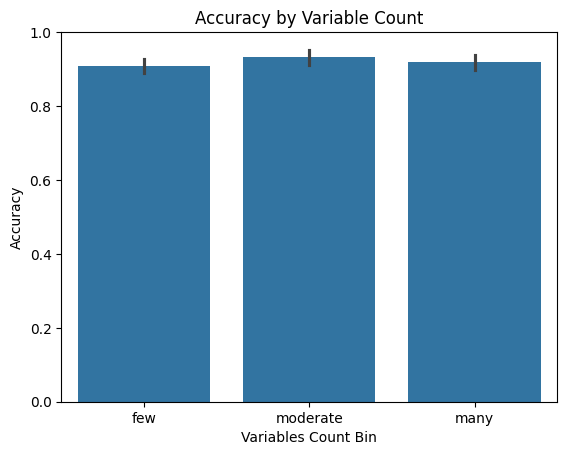

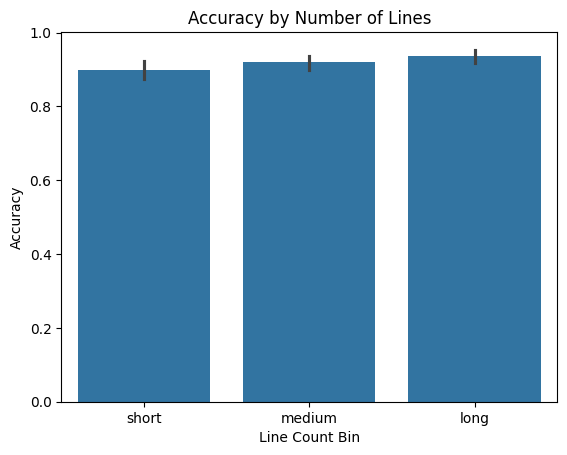

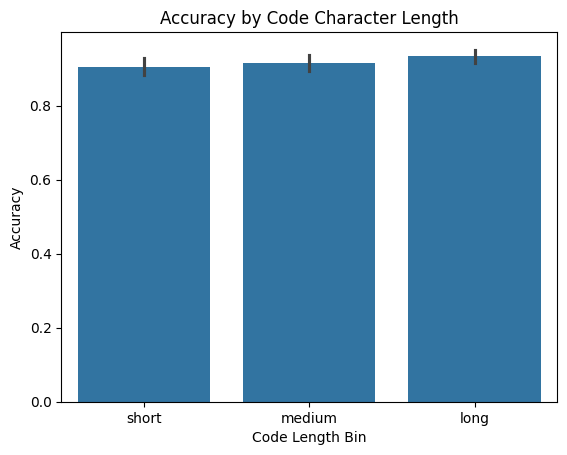

In [ ]:
import seaborn as sns

# --------------------------
# Binning Continuous Features
# --------------------------
test_df['token_bin'] = pd.qcut(test_df['token_count'], 3, labels=["short", "medium", "long"])
test_df['line_bin'] = pd.qcut(test_df['number_of_lines'], 3, labels=["short", "medium", "long"])
test_df['loop_bin'] = pd.qcut(test_df['loop_count'], 3, labels=["low", "medium", "high"])
test_df['cond_bin'] = pd.qcut(test_df['condition_count'], 3, labels=["low", "medium", "high"])
test_df['time_bin'] = pd.qcut(test_df['time_spent_per_question'], 3, labels=["fast", "average", "slow"])
test_df['var_bin'] = pd.qcut(test_df['variables_count'], 3, labels=["few", "moderate", "many"])
test_df['code_len_bin'] = pd.qcut(test_df['question_code_length'], 3, labels=["short", "medium", "long"])

# --------------------------
# 1. Barplot: Accuracy by Token Count Bin
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='token_bin', y='correct')
plt.title("Accuracy by Token Count")
plt.xlabel("Token Count Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 2. Barplot: Accuracy by Loop Count Bin
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='loop_bin', y='correct')
plt.title("Accuracy by Loop Count")
plt.xlabel("Loop Count Bin")
plt.ylabel("Accuracy")
plt.show()


# --------------------------
# 3. Barplot: Conditional Count
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='cond_bin', y='correct')
plt.title("Accuracy by Condition Count")
plt.xlabel("Conditional Count Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 4. Barplot: Time Spent per Question
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='time_bin', y='correct')
plt.title("Accuracy by Time Spent on Question")
plt.xlabel("Time Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 5. Barplot: Variable Count
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='var_bin', y='correct')
plt.title("Accuracy by Variable Count")
plt.xlabel("Variables Count Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 6. Barplot: Number of Lines
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='line_bin', y='correct')
plt.title("Accuracy by Number of Lines")
plt.xlabel("Line Count Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 7. Barplot: Code Character Length
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='code_len_bin', y='correct')
plt.title("Accuracy by Code Character Length")
plt.xlabel("Code Length Bin")
plt.ylabel("Accuracy")
plt.show()
